# HHL + Iterative Refinement: Sensitivity Analysis

Sensitivity of HHL+IR convergence to **problem size** ($n$) and **condition number** ($\kappa$).
All experiments run on `AerSimulator` (statevector-exact).

In [9]:
from pathlib import Path
import sys


def find_repo_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for d in (p, *p.parents):
        if (d / ".git").exists() or (d / "pyproject.toml").exists() or (d / "src").exists():
            return d
    return p


repo_root = find_repo_root()
print(repo_root)

src_dir = repo_root / "src"
if src_dir.exists() and str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from qlsas.algorithms.hhl.hhl import HHL
from qlsas.data_loader import StatePrep
from qlsas.solver import QuantumLinearSolver
from qlsas.refiner import Refiner
from linear_systems_problems.random_matrix_generator_v2 import generate_problem

from datetime import datetime
import numpy as np
import math
import matplotlib.pyplot as plt
from qiskit_aer import AerSimulator

%config InlineBackend.figure_format = "retina"

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

/Users/adrianharkness/QCOL_COPT/HHL/QLSAs


In [10]:
n_values = [4,8,16] #[4, 8, 16, 32]
kappa_values = [10,20,30,40,50] #[5, 10, 15, 20, 25, 30]
num_seeds = 5 #10
max_iter = 20
precision = 1e-30  # run full iterations; apply convergence threshold at visualization time

oracle = "unary"
backend = AerSimulator()


def run_single(n, kappa, seed):
    """Run one HHL+IR instance and return residuals, circuit metadata, and shot stats."""
    prob = generate_problem(n=n, cond_number=kappa, sparsity=0.5, seed=seed)
    A, b = prob["A"], prob["b"]
    A = A / np.linalg.norm(b)
    b = b / np.linalg.norm(b)

    hhl = HHL(
        state_prep=StatePrep(method="default"),
        readout="measure_x",
        num_qpe_qubits=int(math.log2(n)),
        eig_oracle=oracle,
    )
    solver = QuantumLinearSolver(
        qlsa=hhl,
        backend=backend,
        target_successful_shots=1000,
        shots_per_batch=5000,
    )
    refiner = Refiner(A=A, b=b, solver=solver)
    result = refiner.refine(
        precision=precision,
        max_iter=max_iter,
        plot=False,
        verbose=False,
        open_session=False,
    )

    circuit_meta = []
    for circ in result["transpiled_circuits"]:
        circuit_meta.append({
            "depth": circ.depth(),
            "gate_count": circ.size(),
            "num_qubits": circ.num_qubits,
            "cx_count": circ.count_ops().get("cx", 0),
        })

    return {
        "residuals": result["residuals"],
        "circuit_meta": circuit_meta,
        "shot_stats": result.get("shot_stats", []),
        "total_iterations": result["total_iterations"],
    }

In [11]:
results = {}
total = len(n_values) * len(kappa_values) * num_seeds
count = 0

for n in n_values:
    for kappa in kappa_values:
        for seed in range(num_seeds):
            count += 1
            print(f"[{count}/{total}] n={n}, kappa={kappa}, seed={seed}")
            results[(n, kappa, seed)] = run_single(n, kappa, seed)

print(f"\nDone — {len(results)} runs stored.")

[1/75] n=4, kappa=10, seed=0
[2/75] n=4, kappa=10, seed=1
[3/75] n=4, kappa=10, seed=2
[4/75] n=4, kappa=10, seed=3
[5/75] n=4, kappa=10, seed=4
[6/75] n=4, kappa=20, seed=0
[7/75] n=4, kappa=20, seed=1
[8/75] n=4, kappa=20, seed=2
[9/75] n=4, kappa=20, seed=3
[10/75] n=4, kappa=20, seed=4
[11/75] n=4, kappa=30, seed=0
[12/75] n=4, kappa=30, seed=1
[13/75] n=4, kappa=30, seed=2
[14/75] n=4, kappa=30, seed=3
[15/75] n=4, kappa=30, seed=4
[16/75] n=4, kappa=40, seed=0
[17/75] n=4, kappa=40, seed=1
[18/75] n=4, kappa=40, seed=2
[19/75] n=4, kappa=40, seed=3
[20/75] n=4, kappa=40, seed=4
[21/75] n=4, kappa=50, seed=0
[22/75] n=4, kappa=50, seed=1
[23/75] n=4, kappa=50, seed=2
[24/75] n=4, kappa=50, seed=3
[25/75] n=4, kappa=50, seed=4
[26/75] n=8, kappa=10, seed=0
[27/75] n=8, kappa=10, seed=1
[28/75] n=8, kappa=10, seed=2
[29/75] n=8, kappa=10, seed=3
[30/75] n=8, kappa=10, seed=4
[31/75] n=8, kappa=20, seed=0
[32/75] n=8, kappa=20, seed=1
[33/75] n=8, kappa=20, seed=2
[34/75] n=8, kappa=

In [12]:
def get_residuals(results, n, kappa, seed):
    """Extract the residuals list from a result entry."""
    entry = results[(n, kappa, seed)]
    return entry["residuals"] if isinstance(entry, dict) else entry


def get_log_residual_matrix(results, n, kappa, num_seeds, max_iter):
    """Return (num_seeds x max_iter) array of log10 residuals for a fixed (n, kappa)."""
    mat = np.full((num_seeds, max_iter), np.nan)
    for seed in range(num_seeds):
        res = get_residuals(results, n, kappa, seed)
        length = min(len(res), max_iter)
        mat[seed, :length] = np.log10(np.maximum(res[:length], 1e-16))
    return mat


def compute_convergence_rate(log_residuals_1d):
    """Fit slope of log10(residual) vs iteration via least-squares."""
    valid = ~np.isnan(log_residuals_1d)
    y = log_residuals_1d[valid]
    x = np.arange(len(log_residuals_1d))[valid]
    if len(x) < 2:
        return np.nan
    coeffs = np.polyfit(x, y, 1)
    return coeffs[0]


def iterations_to_threshold(residuals, threshold=1e-8):
    """Return first iteration where residual <= threshold, or len(residuals) if never reached."""
    for i, r in enumerate(residuals):
        if r <= threshold:
            return i
    return len(residuals)


def get_circuit_meta_matrix(results, n, kappa, num_seeds, max_iter, field="gate_count"):
    """Return (num_seeds x max_iter) array of a circuit metadata field."""
    mat = np.full((num_seeds, max_iter), np.nan)
    for seed in range(num_seeds):
        entry = results[(n, kappa, seed)]
        if not isinstance(entry, dict) or "circuit_meta" not in entry:
            continue
        meta = entry["circuit_meta"]
        for i, m in enumerate(meta[:max_iter]):
            mat[seed, i] = m[field]
    return mat


def get_success_prob_matrix(results, n, kappa, num_seeds, max_iter):
    """Return (num_seeds x max_iter) array of per-iteration post-selection success probabilities."""
    mat = np.full((num_seeds, max_iter), np.nan)
    for seed in range(num_seeds):
        entry = results[(n, kappa, seed)]
        if not isinstance(entry, dict) or "shot_stats" not in entry:
            continue
        stats = entry["shot_stats"]
        for i, s in enumerate(stats[:max_iter]):
            if s.get("success_probability") is not None:
                mat[seed, i] = s["success_probability"]
    return mat


def get_total_shots_matrix(results, n, kappa, num_seeds, max_iter):
    """Return (num_seeds x max_iter) array of total shots submitted per iteration."""
    mat = np.full((num_seeds, max_iter), np.nan)
    for seed in range(num_seeds):
        entry = results[(n, kappa, seed)]
        if not isinstance(entry, dict) or "shot_stats" not in entry:
            continue
        stats = entry["shot_stats"]
        for i, s in enumerate(stats[:max_iter]):
            if s.get("total_shots_submitted") is not None:
                mat[seed, i] = s["total_shots_submitted"]
    return mat

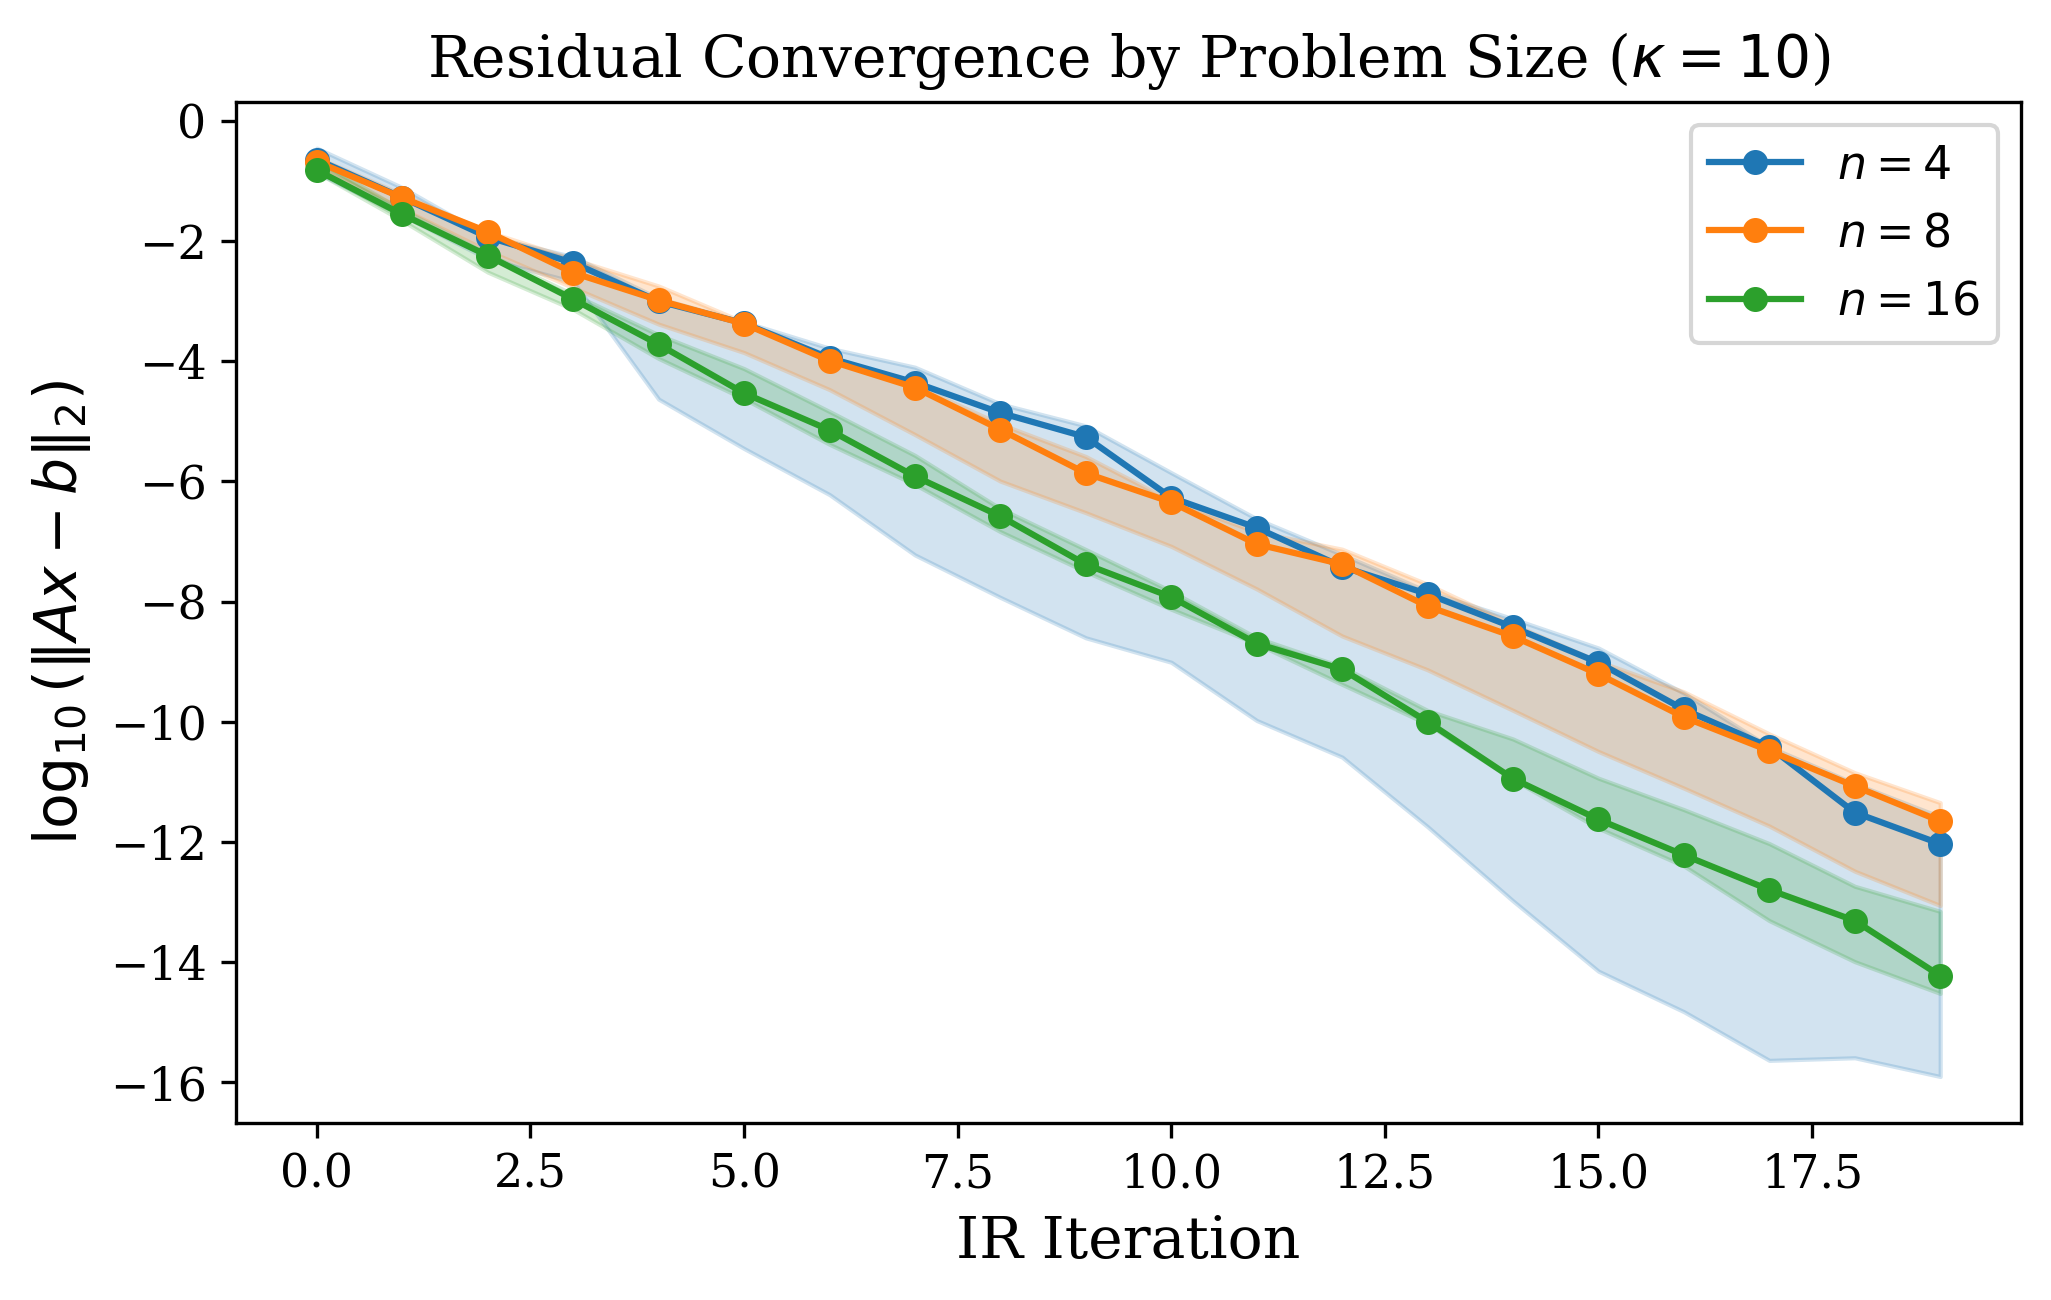

In [13]:
fig, ax = plt.subplots(figsize=(7, 4.5))

fixed_kappa = 10
size_subset = [4, 8, 16]

for n in size_subset:
    mat = get_log_residual_matrix(results, n, fixed_kappa, num_seeds, max_iter)
    median = np.nanmedian(mat, axis=0)
    q25 = np.nanpercentile(mat, 25, axis=0)
    q75 = np.nanpercentile(mat, 75, axis=0)
    iters = np.arange(max_iter)

    color = ax.plot(iters, median, "o-", label=f"$n = {n}$", markersize=5)[0].get_color()
    ax.fill_between(iters, q25, q75, alpha=0.2, color=color)

ax.set_xlabel("IR Iteration")
ax.set_ylabel(r"$\log_{10}(\|Ax - b\|_2)$")
ax.set_title(rf"Residual Convergence by Problem Size ($\kappa = {fixed_kappa}$)")
ax.legend()
plt.tight_layout()
plt.savefig(
    f"../data/sensitivity_size_bands_kappa{fixed_kappa}_{backend.name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pdf"
)
plt.show()

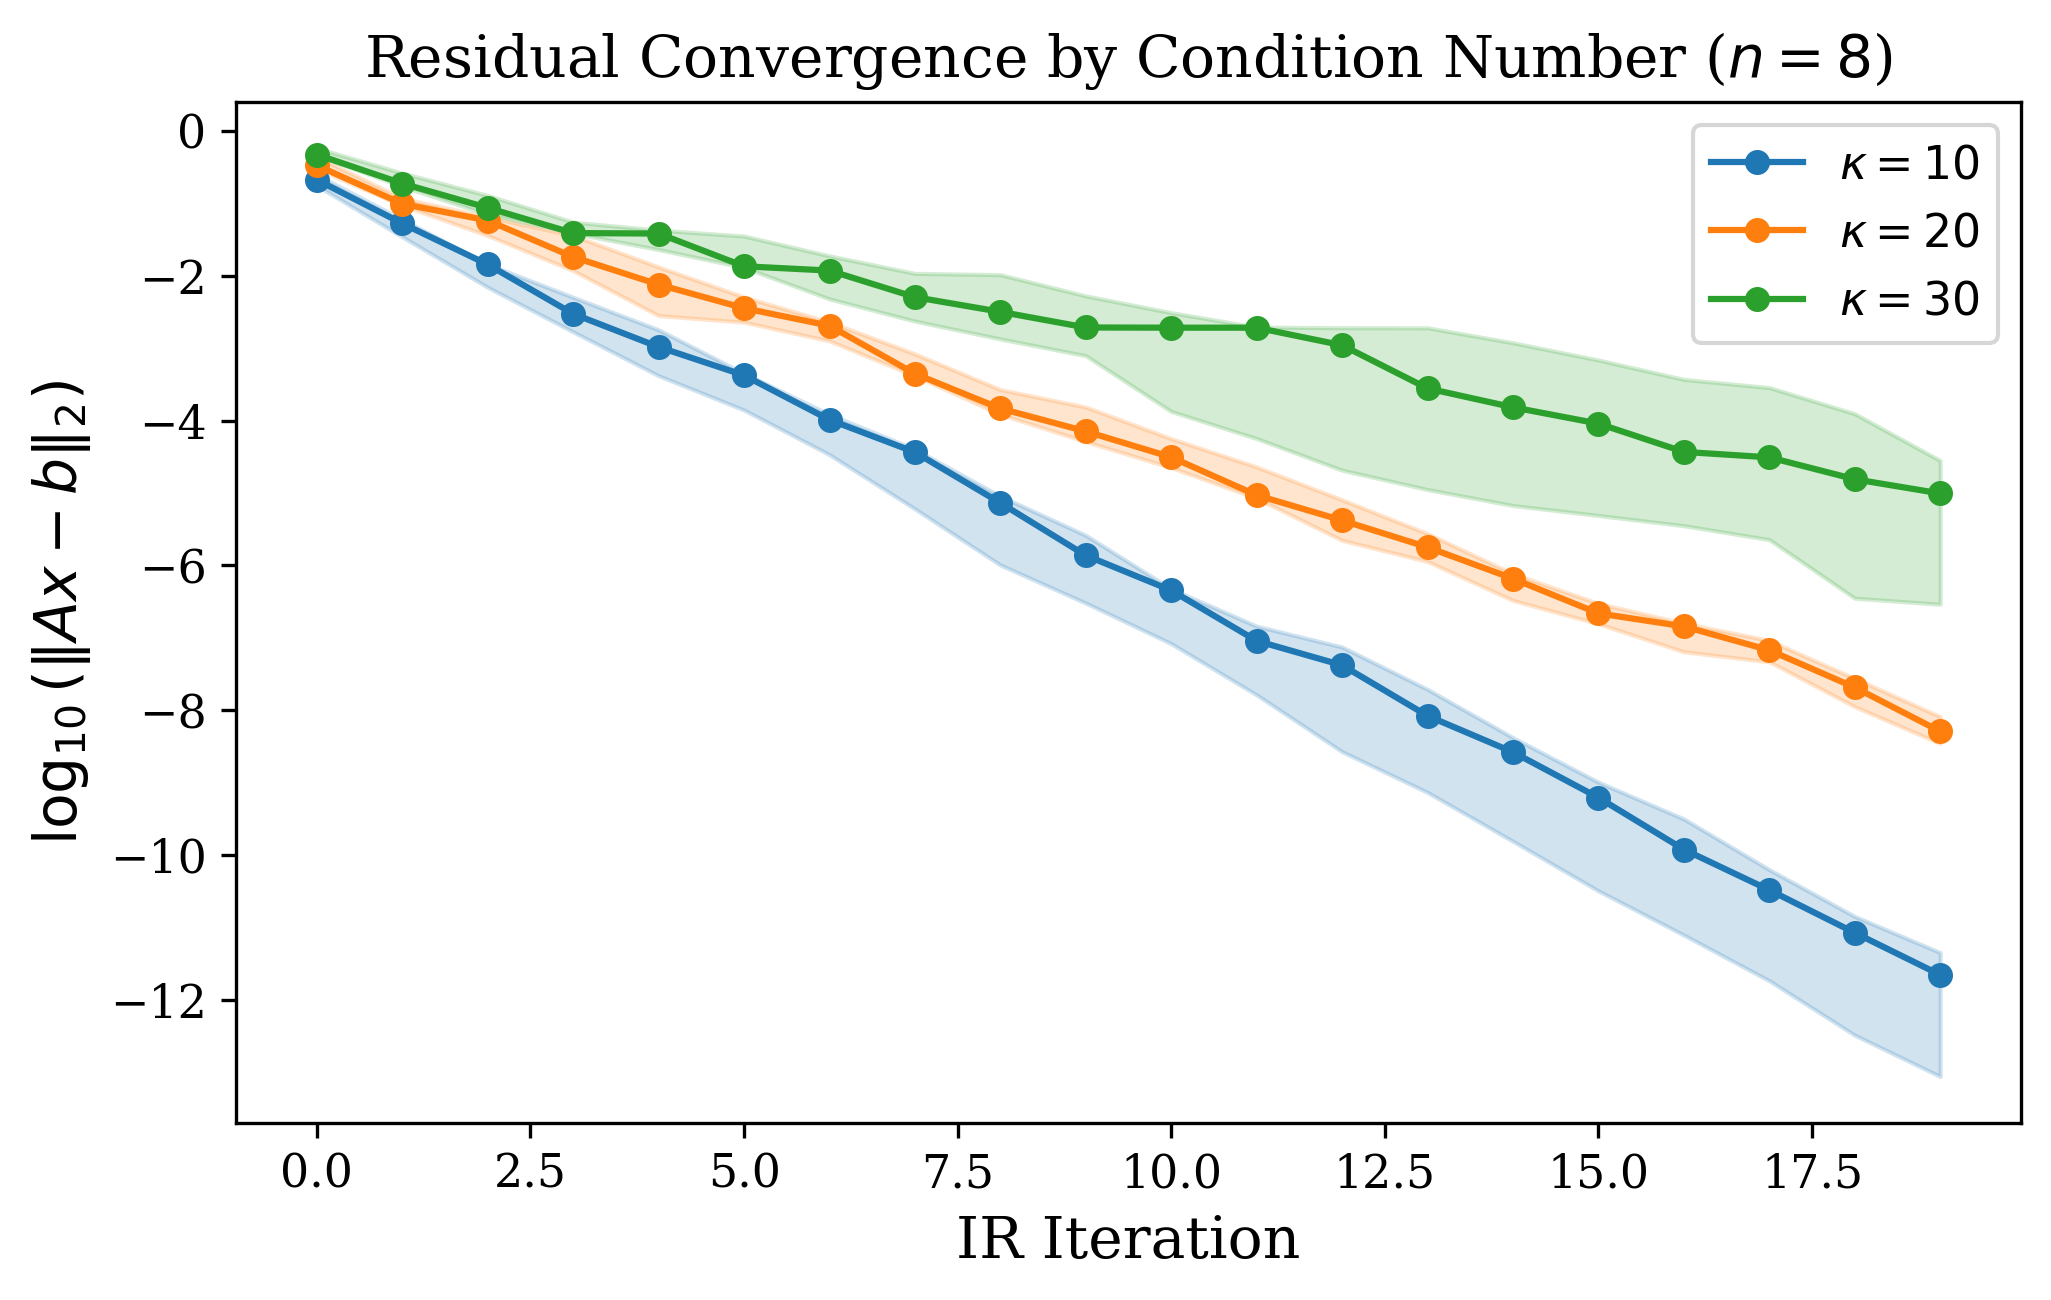

In [22]:
fig, ax = plt.subplots(figsize=(7, 4.5))

fixed_n = 8
kappa_subset = [10, 20, 30]

for kappa in kappa_subset:
    mat = get_log_residual_matrix(results, fixed_n, kappa, num_seeds, max_iter)
    median = np.nanmedian(mat, axis=0)
    q25 = np.nanpercentile(mat, 25, axis=0)
    q75 = np.nanpercentile(mat, 75, axis=0)
    iters = np.arange(max_iter)

    color = ax.plot(iters, median, "o-", label=rf"$\kappa = {kappa}$", markersize=5)[0].get_color()
    ax.fill_between(iters, q25, q75, alpha=0.2, color=color)

ax.set_xlabel("IR Iteration")
ax.set_ylabel(r"$\log_{10}(\|Ax - b\|_2)$")
ax.set_title(rf"Residual Convergence by Condition Number ($n = {fixed_n}$)")
ax.legend()
plt.tight_layout()
plt.savefig(
    f"../data/sensitivity_kappa_bands_n{fixed_n}_{backend.name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pdf"
)
plt.show()

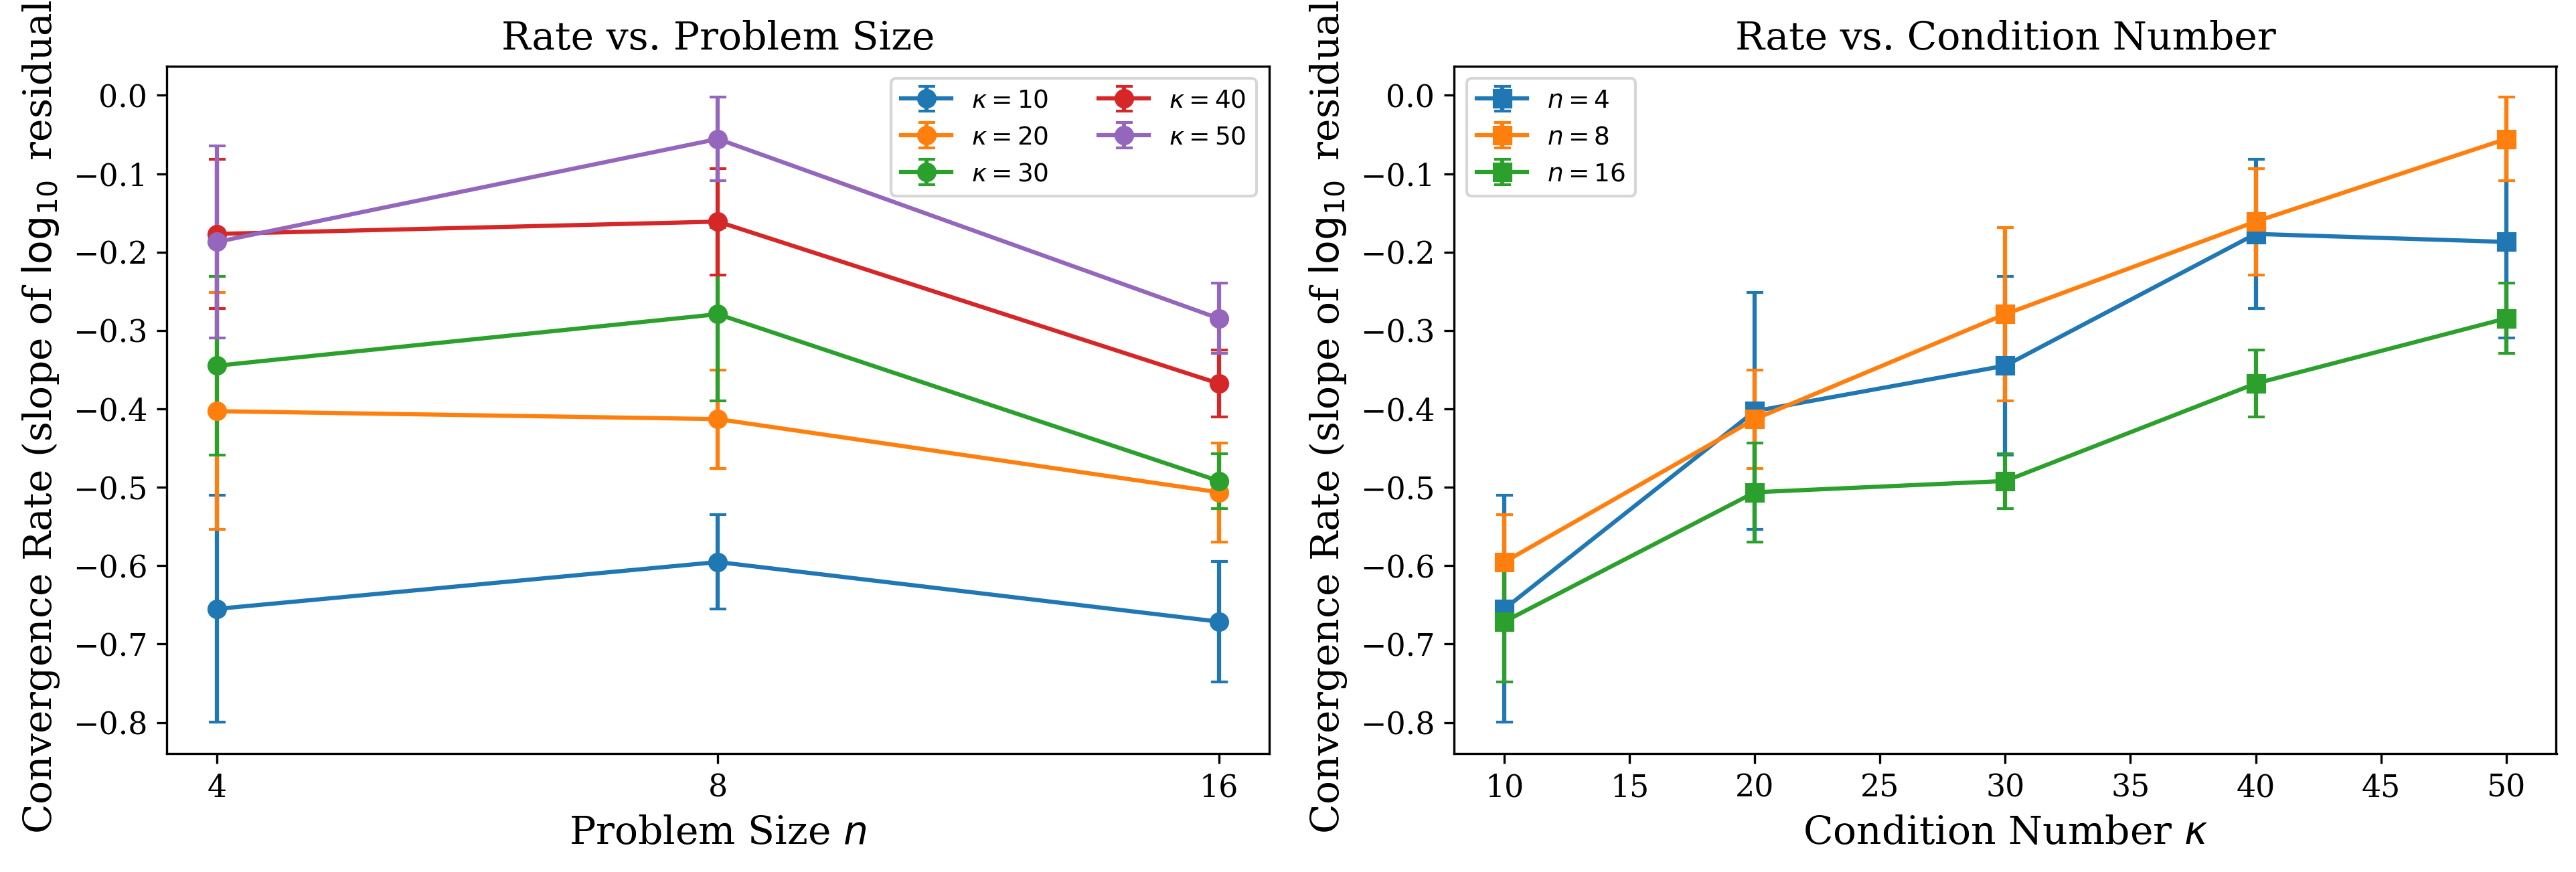

In [15]:
rates = np.full((len(n_values), len(kappa_values), num_seeds), np.nan)

for i, n in enumerate(n_values):
    for j, kappa in enumerate(kappa_values):
        mat = get_log_residual_matrix(results, n, kappa, num_seeds, max_iter)
        for s in range(num_seeds):
            rates[i, j, s] = compute_convergence_rate(mat[s])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: convergence rate vs n, one line per kappa
for j, kappa in enumerate(kappa_values):
    mean_rate = np.nanmean(rates[:, j, :], axis=1)
    std_rate = np.nanstd(rates[:, j, :], axis=1)
    ax1.errorbar(
        n_values, mean_rate, yerr=std_rate,
        fmt="o-", capsize=3, label=rf"$\kappa = {kappa}$",
    )

ax1.set_xlabel("Problem Size $n$")
ax1.set_ylabel("Convergence Rate (slope of $\\log_{10}$ residual)")
ax1.set_title("Rate vs. Problem Size")
ax1.set_xscale("log", base=2)
ax1.set_xticks(n_values)
ax1.set_xticklabels([str(v) for v in n_values])
ax1.legend(fontsize=9, ncol=2)

# Right: convergence rate vs kappa, one line per n
for i, n in enumerate(n_values):
    mean_rate = np.nanmean(rates[i, :, :], axis=1)
    std_rate = np.nanstd(rates[i, :, :], axis=1)
    ax2.errorbar(
        kappa_values, mean_rate, yerr=std_rate,
        fmt="s-", capsize=3, label=f"$n = {n}$",
    )

ax2.set_xlabel(r"Condition Number $\kappa$")
ax2.set_ylabel("Convergence Rate (slope of $\\log_{10}$ residual)")
ax2.set_title("Rate vs. Condition Number")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(
    f"../data/sensitivity_convergence_rates_{backend.name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pdf"
)
plt.show()

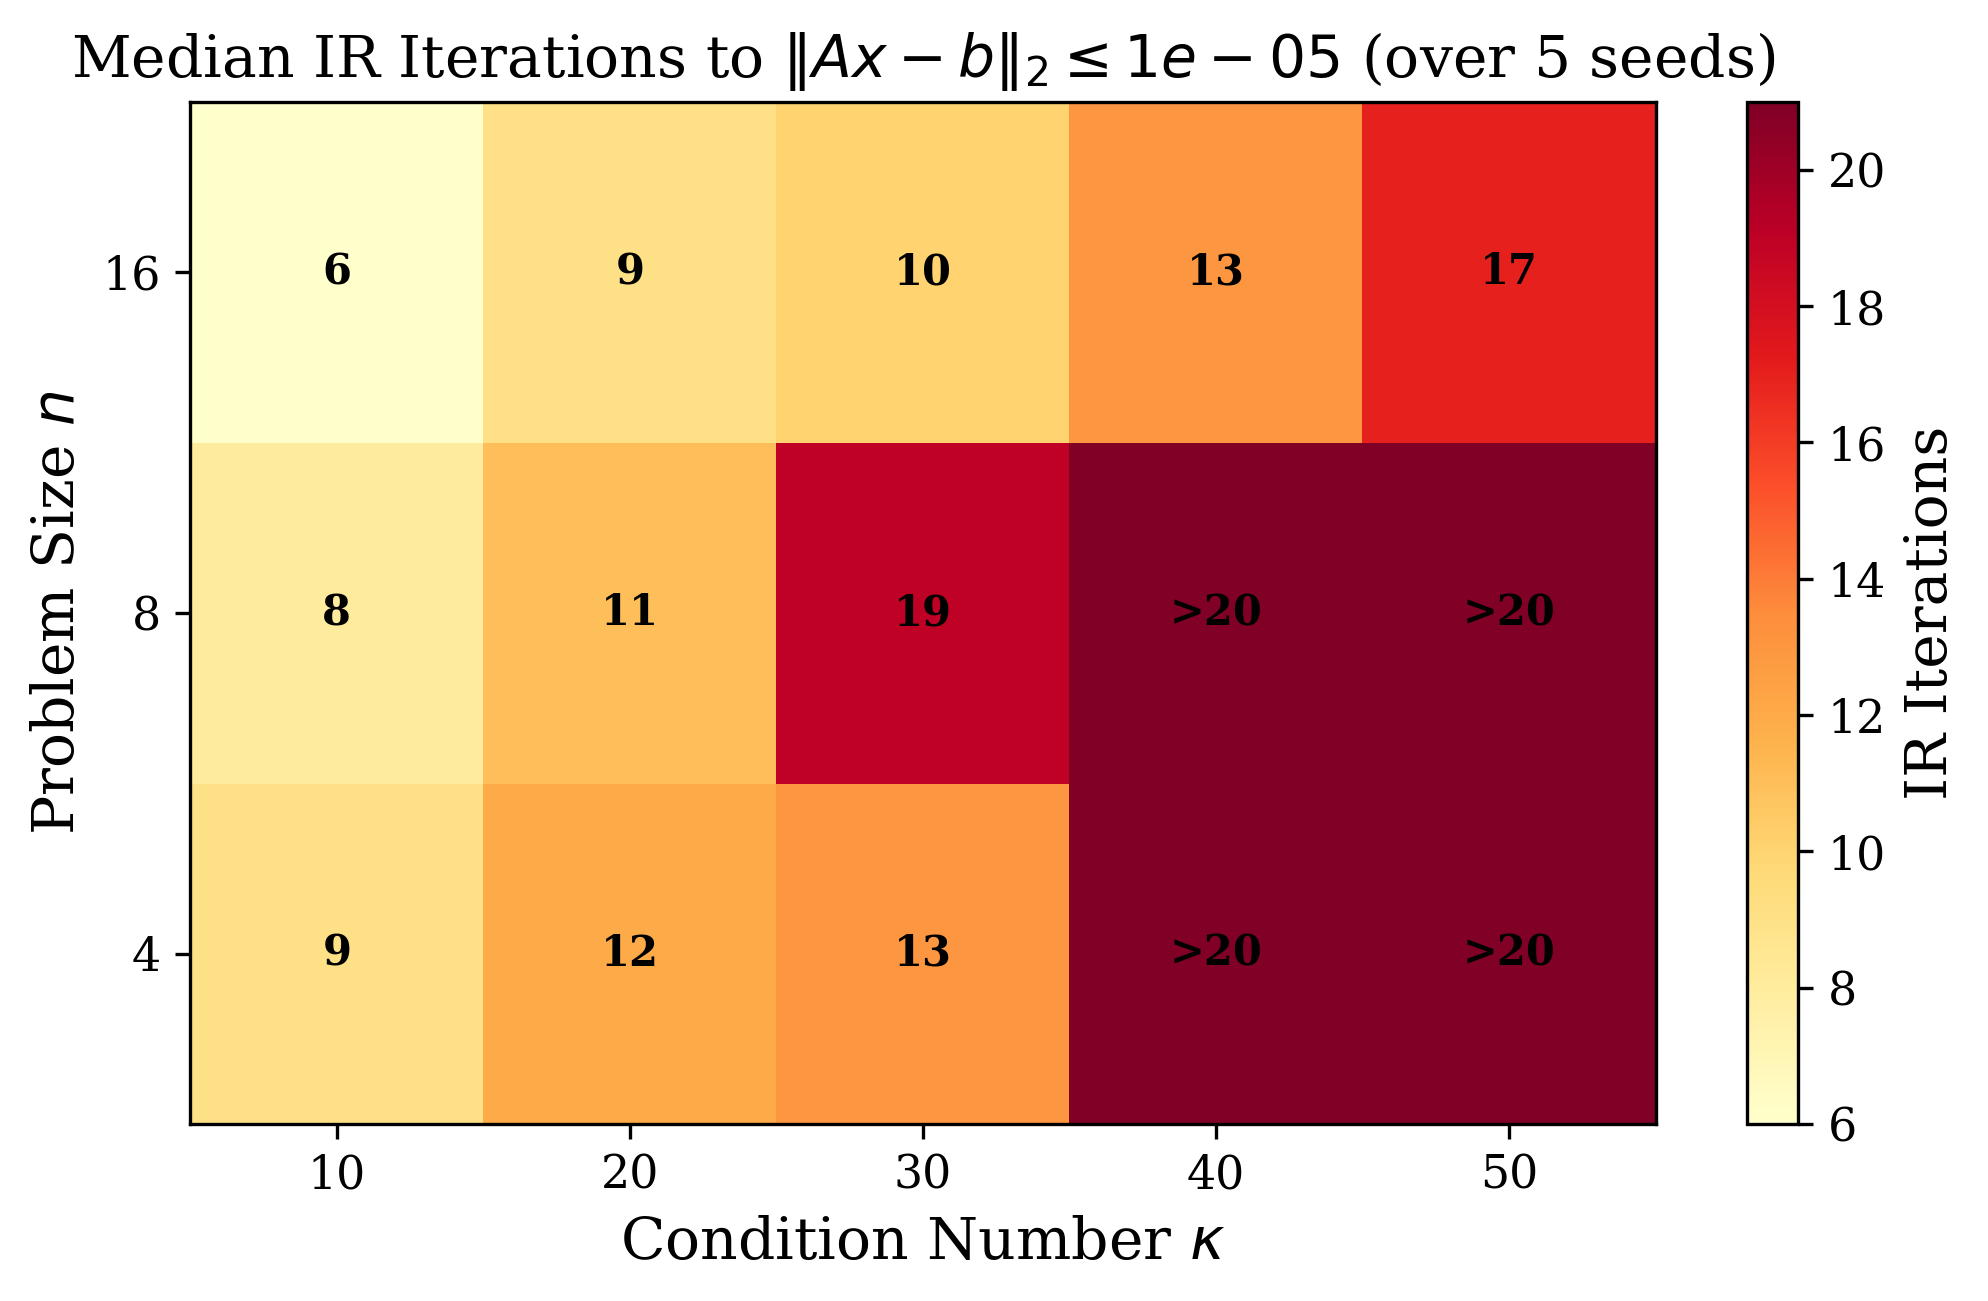

In [23]:
convergence_threshold = 1e-5

iters_grid = np.full((len(n_values), len(kappa_values), num_seeds), np.nan)
for i, n in enumerate(n_values):
    for j, kappa in enumerate(kappa_values):
        for s in range(num_seeds):
            iters_grid[i, j, s] = iterations_to_threshold(
                get_residuals(results, n, kappa, s), threshold=convergence_threshold
            )

median_iters = np.nanmedian(iters_grid, axis=2)

fig, ax = plt.subplots(figsize=(7, 4.5))
im = ax.imshow(
    median_iters,
    origin="lower",
    aspect="auto",
    cmap="YlOrRd",
    interpolation="nearest",
)

for i in range(len(n_values)):
    for j in range(len(kappa_values)):
        val = median_iters[i, j]
        label = f"{val:.0f}" if val < max_iter else f">{max_iter}"
        ax.text(j, i, label, ha="center", va="center", fontsize=10, fontweight="bold")

ax.set_xticks(range(len(kappa_values)))
ax.set_xticklabels([str(k) for k in kappa_values])
ax.set_yticks(range(len(n_values)))
ax.set_yticklabels([str(n) for n in n_values])
ax.set_xlabel(r"Condition Number $\kappa$")
ax.set_ylabel("Problem Size $n$")
ax.set_title(
    rf"Median IR Iterations to $\|Ax - b\|_2 \leq {convergence_threshold:.0e}$ (over {num_seeds} seeds)"
)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("IR Iterations")

plt.tight_layout()
plt.savefig(
    f"../data/sensitivity_heatmap_iters_{backend.name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pdf"
)
plt.show()

### Circuit cost, gate counts, and post-selection probability

/var/folders/zv/92_qyn4s5v7f__ysxhlg_ykw0000gn/T/ipykernel_79068/2102969624.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


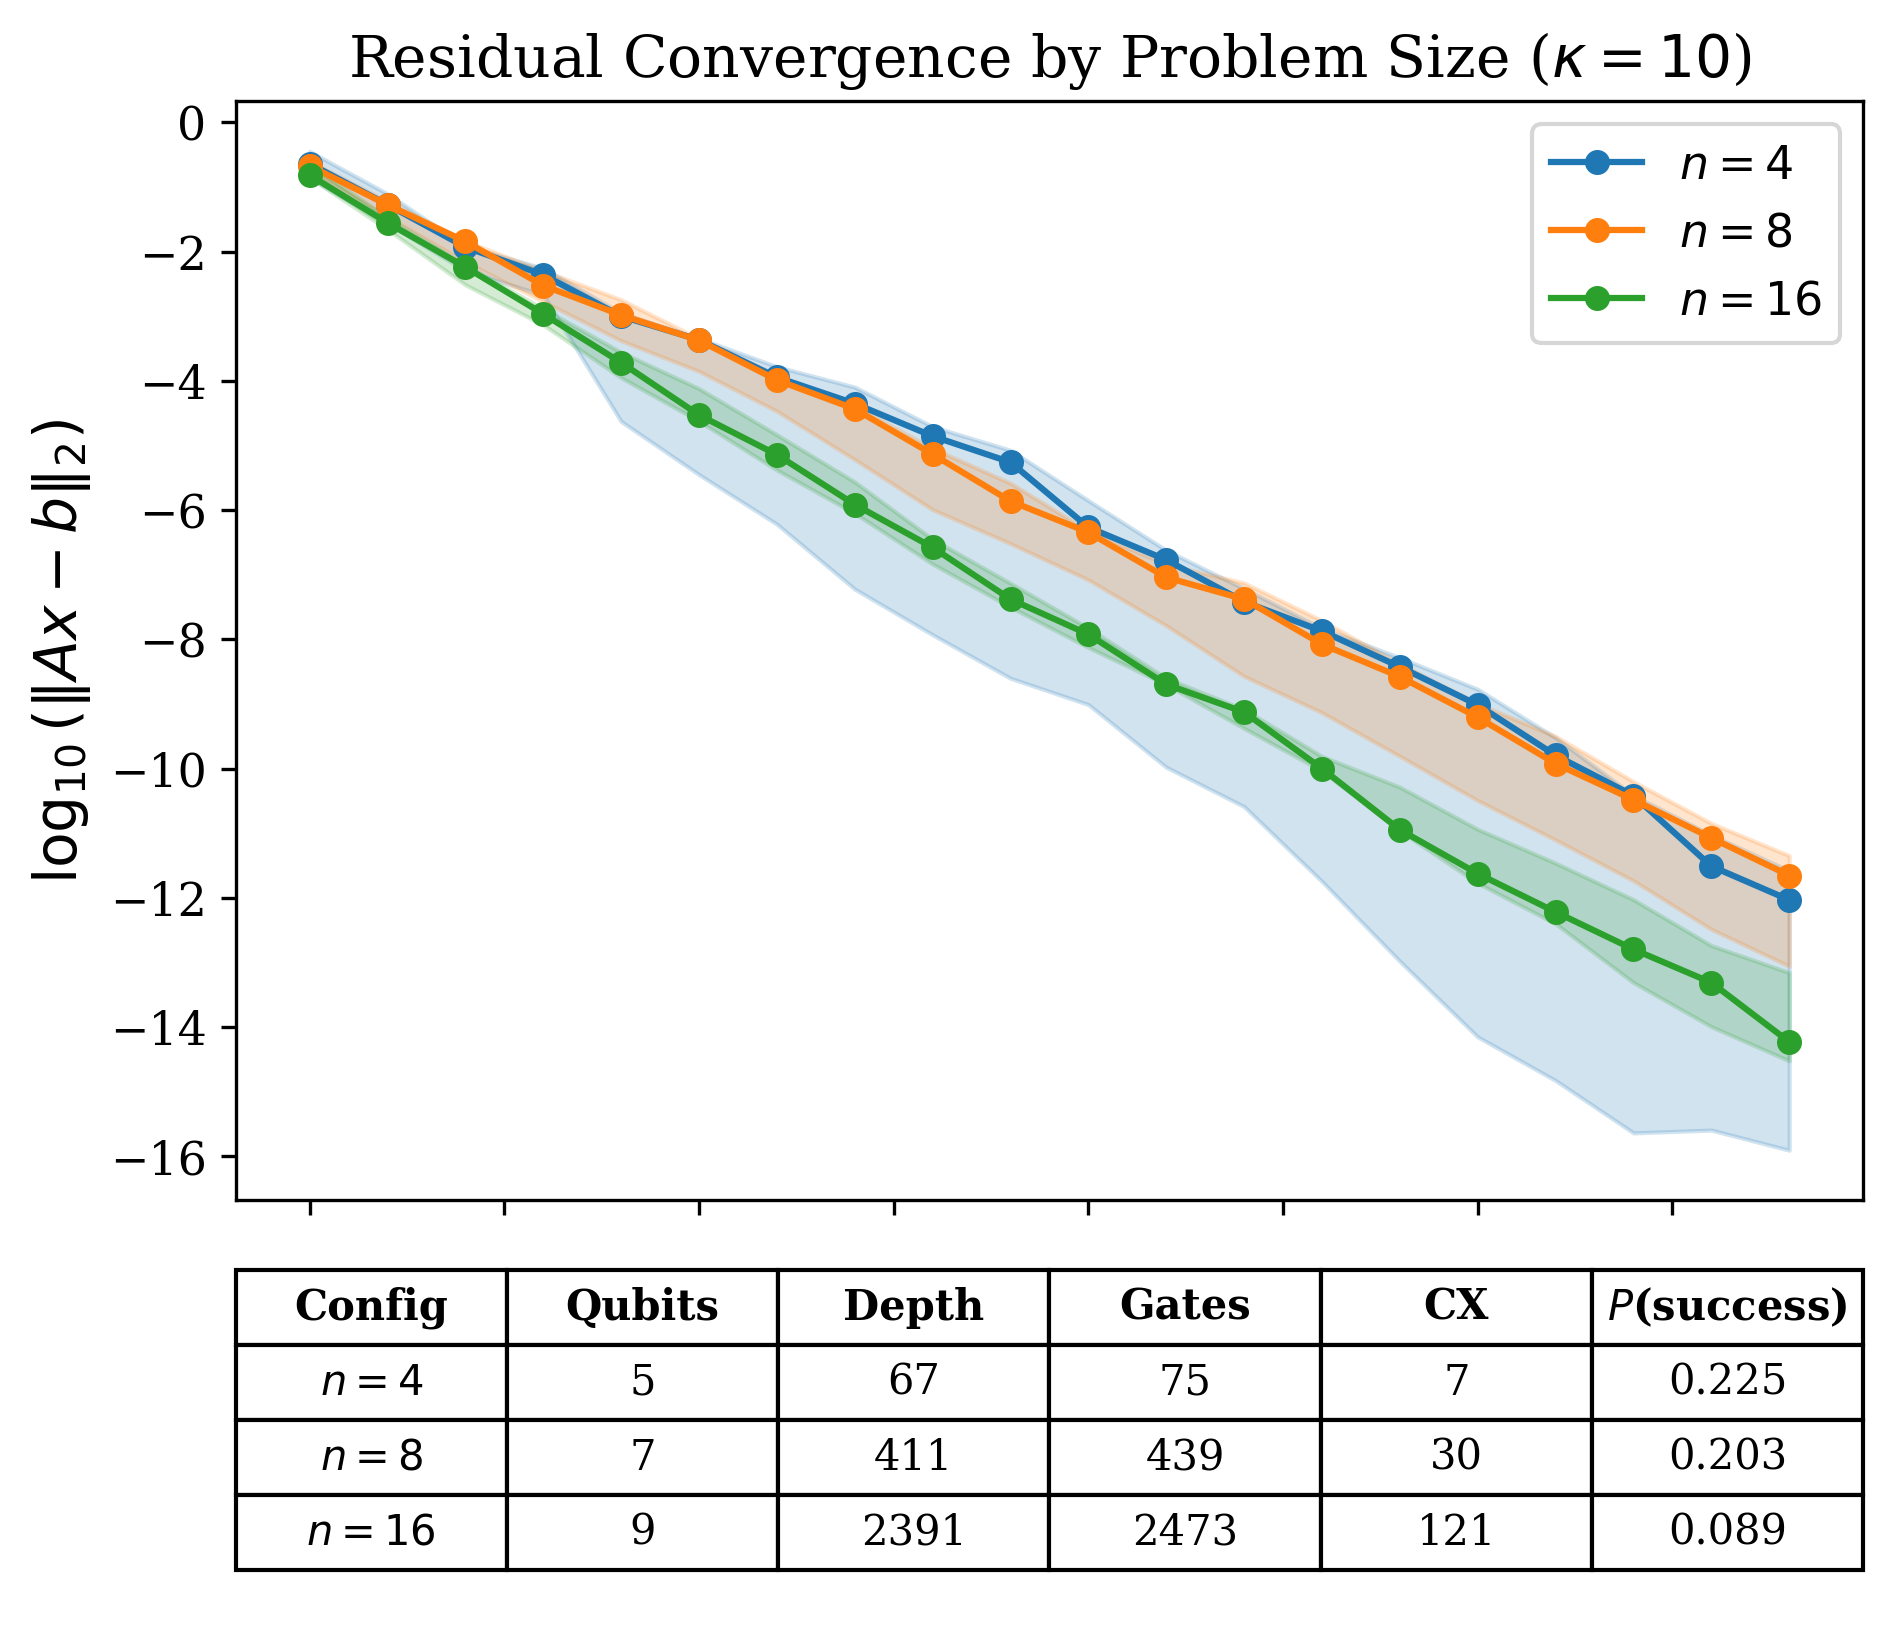

In [17]:
fixed_kappa_for_table = 10
size_subset_for_table = [4, 8, 16]

fig = plt.figure(figsize=(7, 6.5))
gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.05)
ax = fig.add_subplot(gs[0])

table_rows = []
for n in size_subset_for_table:
    mat = get_log_residual_matrix(results, n, fixed_kappa_for_table, num_seeds, max_iter)
    median = np.nanmedian(mat, axis=0)
    q25 = np.nanpercentile(mat, 25, axis=0)
    q75 = np.nanpercentile(mat, 75, axis=0)
    iters = np.arange(max_iter)
    color = ax.plot(iters, median, "o-", label=f"$n = {n}$", markersize=5)[0].get_color()
    ax.fill_between(iters, q25, q75, alpha=0.2, color=color)

    depths = get_circuit_meta_matrix(results, n, fixed_kappa_for_table, num_seeds, max_iter, "depth")
    gates = get_circuit_meta_matrix(results, n, fixed_kappa_for_table, num_seeds, max_iter, "gate_count")
    cxs = get_circuit_meta_matrix(results, n, fixed_kappa_for_table, num_seeds, max_iter, "cx_count")
    qubits = get_circuit_meta_matrix(results, n, fixed_kappa_for_table, num_seeds, max_iter, "num_qubits")
    probs = get_success_prob_matrix(results, n, fixed_kappa_for_table, num_seeds, max_iter)

    table_rows.append([
        f"$n={n}$",
        f"{int(np.nanmedian(qubits))}",
        f"{np.nanmedian(depths):.0f}",
        f"{np.nanmedian(gates):.0f}",
        f"{np.nanmedian(cxs):.0f}",
        f"{np.nanmean(probs):.3f}",
    ])

ax.set_ylabel(r"$\log_{10}(\|Ax - b\|_2)$")
ax.set_title(rf"Residual Convergence by Problem Size ($\kappa = {fixed_kappa_for_table}$)")
ax.legend()
ax.set_xticklabels([])

ax_table = fig.add_subplot(gs[1])
ax_table.axis("off")
col_labels = ["Config", "Qubits", "Depth", "Gates", "CX", "$P$(success)"]
tbl = ax_table.table(cellText=table_rows, colLabels=col_labels, loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.5)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_text_props(fontweight="bold")

plt.tight_layout()
plt.savefig(
    f"../data/sensitivity_size_with_table_{backend.name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pdf"
)
plt.show()


/var/folders/zv/92_qyn4s5v7f__ysxhlg_ykw0000gn/T/ipykernel_79068/1862024098.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


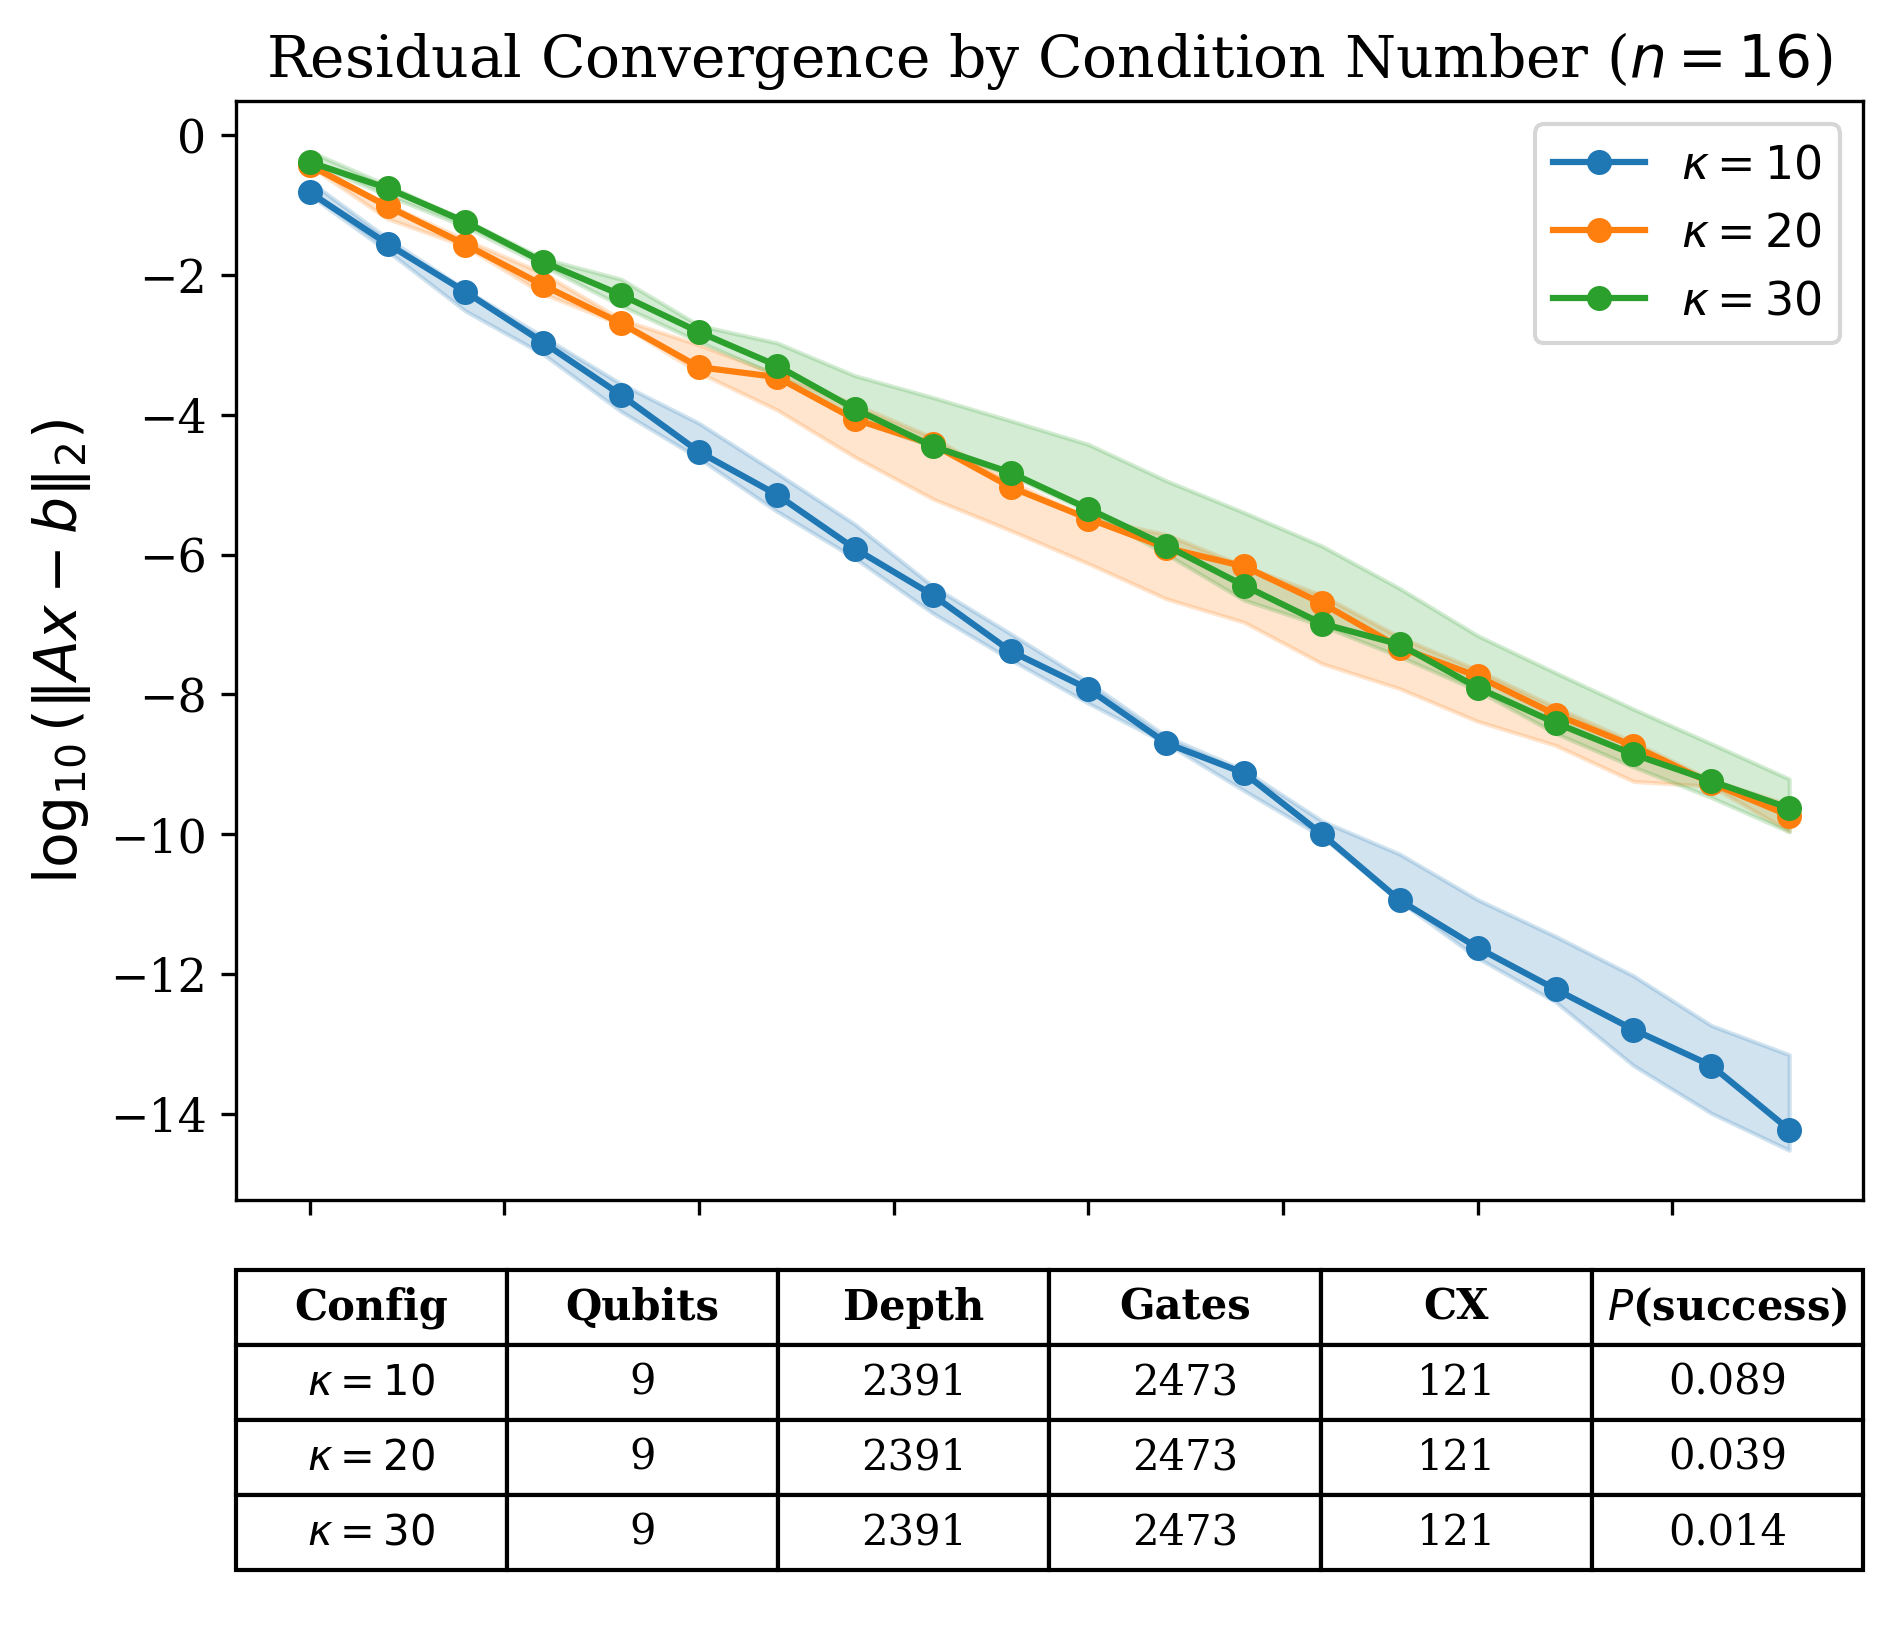

In [18]:
fixed_n_for_table = 16
kappa_subset_for_table = [10, 20, 30]

fig = plt.figure(figsize=(7, 6.5))
gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.05)
ax = fig.add_subplot(gs[0])

table_rows = []
for kappa in kappa_subset_for_table:
    mat = get_log_residual_matrix(results, fixed_n_for_table, kappa, num_seeds, max_iter)
    median = np.nanmedian(mat, axis=0)
    q25 = np.nanpercentile(mat, 25, axis=0)
    q75 = np.nanpercentile(mat, 75, axis=0)
    iters = np.arange(max_iter)
    color = ax.plot(iters, median, "o-", label=rf"$\kappa = {kappa}$", markersize=5)[0].get_color()
    ax.fill_between(iters, q25, q75, alpha=0.2, color=color)

    depths = get_circuit_meta_matrix(results, fixed_n_for_table, kappa, num_seeds, max_iter, "depth")
    gates = get_circuit_meta_matrix(results, fixed_n_for_table, kappa, num_seeds, max_iter, "gate_count")
    cxs = get_circuit_meta_matrix(results, fixed_n_for_table, kappa, num_seeds, max_iter, "cx_count")
    qubits = get_circuit_meta_matrix(results, fixed_n_for_table, kappa, num_seeds, max_iter, "num_qubits")
    probs = get_success_prob_matrix(results, fixed_n_for_table, kappa, num_seeds, max_iter)

    table_rows.append([
        rf"$\kappa={kappa}$",
        f"{int(np.nanmedian(qubits))}",
        f"{np.nanmedian(depths):.0f}",
        f"{np.nanmedian(gates):.0f}",
        f"{np.nanmedian(cxs):.0f}",
        f"{np.nanmean(probs):.3f}",
    ])

ax.set_ylabel(r"$\log_{10}(\|Ax - b\|_2)$")
ax.set_title(rf"Residual Convergence by Condition Number ($n = {fixed_n_for_table}$)")
ax.legend()
ax.set_xticklabels([])

ax_table = fig.add_subplot(gs[1])
ax_table.axis("off")
col_labels = ["Config", "Qubits", "Depth", "Gates", "CX", "$P$(success)"]
tbl = ax_table.table(cellText=table_rows, colLabels=col_labels, loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.5)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_text_props(fontweight="bold")

plt.tight_layout()
plt.savefig(
    f"../data/sensitivity_kappa_with_table_{backend.name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pdf"
)
plt.show()


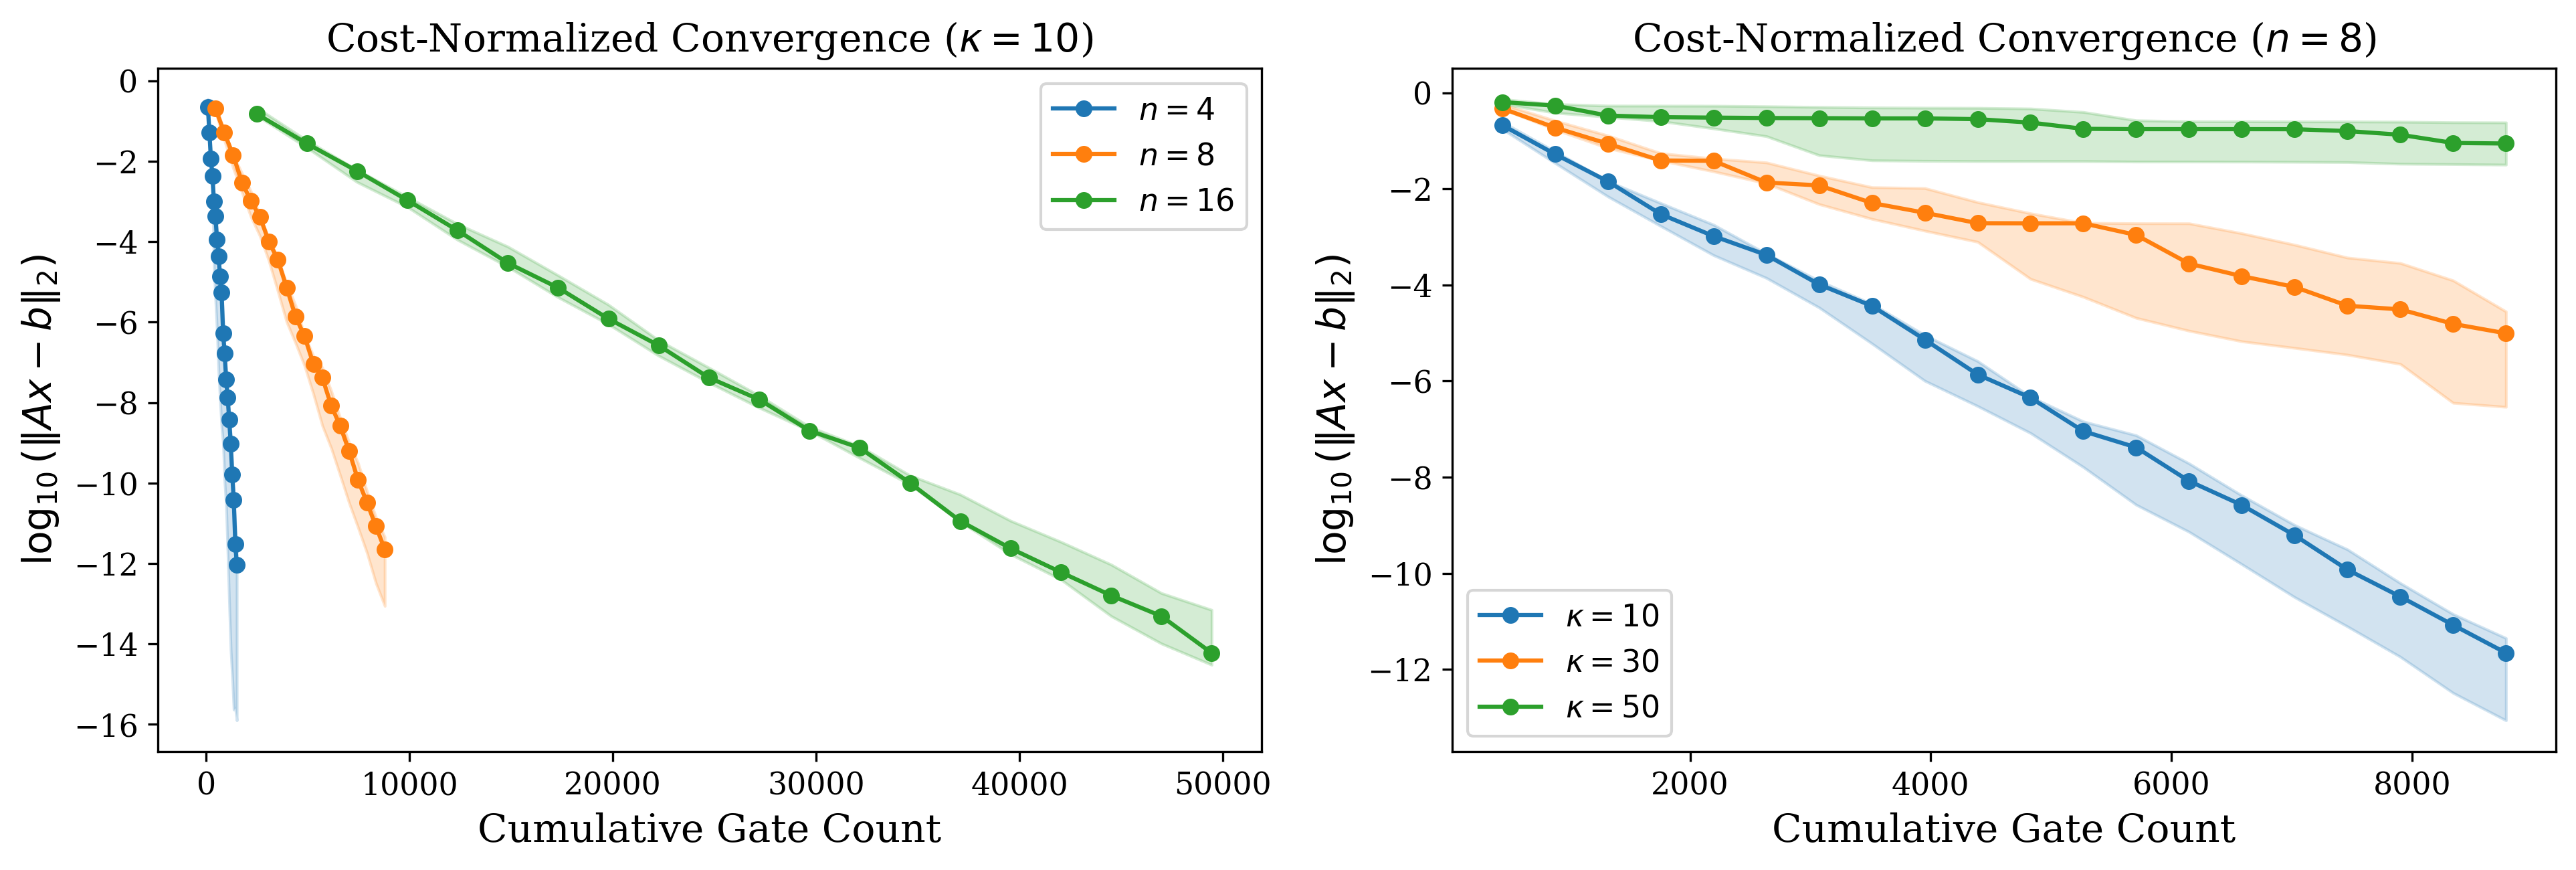

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: residual vs cumulative gate count, varying problem size
cost_fixed_kappa = kappa_values[0]
for n in n_values:
    log_res = get_log_residual_matrix(results, n, cost_fixed_kappa, num_seeds, max_iter)
    gates = get_circuit_meta_matrix(results, n, cost_fixed_kappa, num_seeds, max_iter, "gate_count")
    cum_gates = np.nancumsum(gates, axis=1)
    median_res = np.nanmedian(log_res, axis=0)
    median_cost = np.nanmedian(cum_gates, axis=0)
    q25 = np.nanpercentile(log_res, 25, axis=0)
    q75 = np.nanpercentile(log_res, 75, axis=0)
    color = ax1.plot(median_cost, median_res, "o-", label=f"$n = {n}$", markersize=5)[0].get_color()
    ax1.fill_between(median_cost, q25, q75, alpha=0.2, color=color)

ax1.set_xlabel("Cumulative Gate Count")
ax1.set_ylabel(r"$\log_{10}(\|Ax - b\|_2)$")
ax1.set_title(rf"Cost-Normalized Convergence ($\kappa = {cost_fixed_kappa}$)")
ax1.legend()

# Right: residual vs cumulative gate count, varying condition number
cost_fixed_n = n_values[len(n_values) // 2]
kappa_sub = kappa_values[::2] if len(kappa_values) > 4 else kappa_values
for kappa in kappa_sub:
    log_res = get_log_residual_matrix(results, cost_fixed_n, kappa, num_seeds, max_iter)
    gates = get_circuit_meta_matrix(results, cost_fixed_n, kappa, num_seeds, max_iter, "gate_count")
    cum_gates = np.nancumsum(gates, axis=1)
    median_res = np.nanmedian(log_res, axis=0)
    median_cost = np.nanmedian(cum_gates, axis=0)
    q25 = np.nanpercentile(log_res, 25, axis=0)
    q75 = np.nanpercentile(log_res, 75, axis=0)
    color = ax2.plot(median_cost, median_res, "o-", label=rf"$\kappa = {kappa}$", markersize=5)[0].get_color()
    ax2.fill_between(median_cost, q25, q75, alpha=0.2, color=color)

ax2.set_xlabel("Cumulative Gate Count")
ax2.set_ylabel(r"$\log_{10}(\|Ax - b\|_2)$")
ax2.set_title(rf"Cost-Normalized Convergence ($n = {cost_fixed_n}$)")
ax2.legend()

plt.tight_layout()
plt.savefig(
    f"../data/sensitivity_cost_normalized_{backend.name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pdf"
)
plt.show()


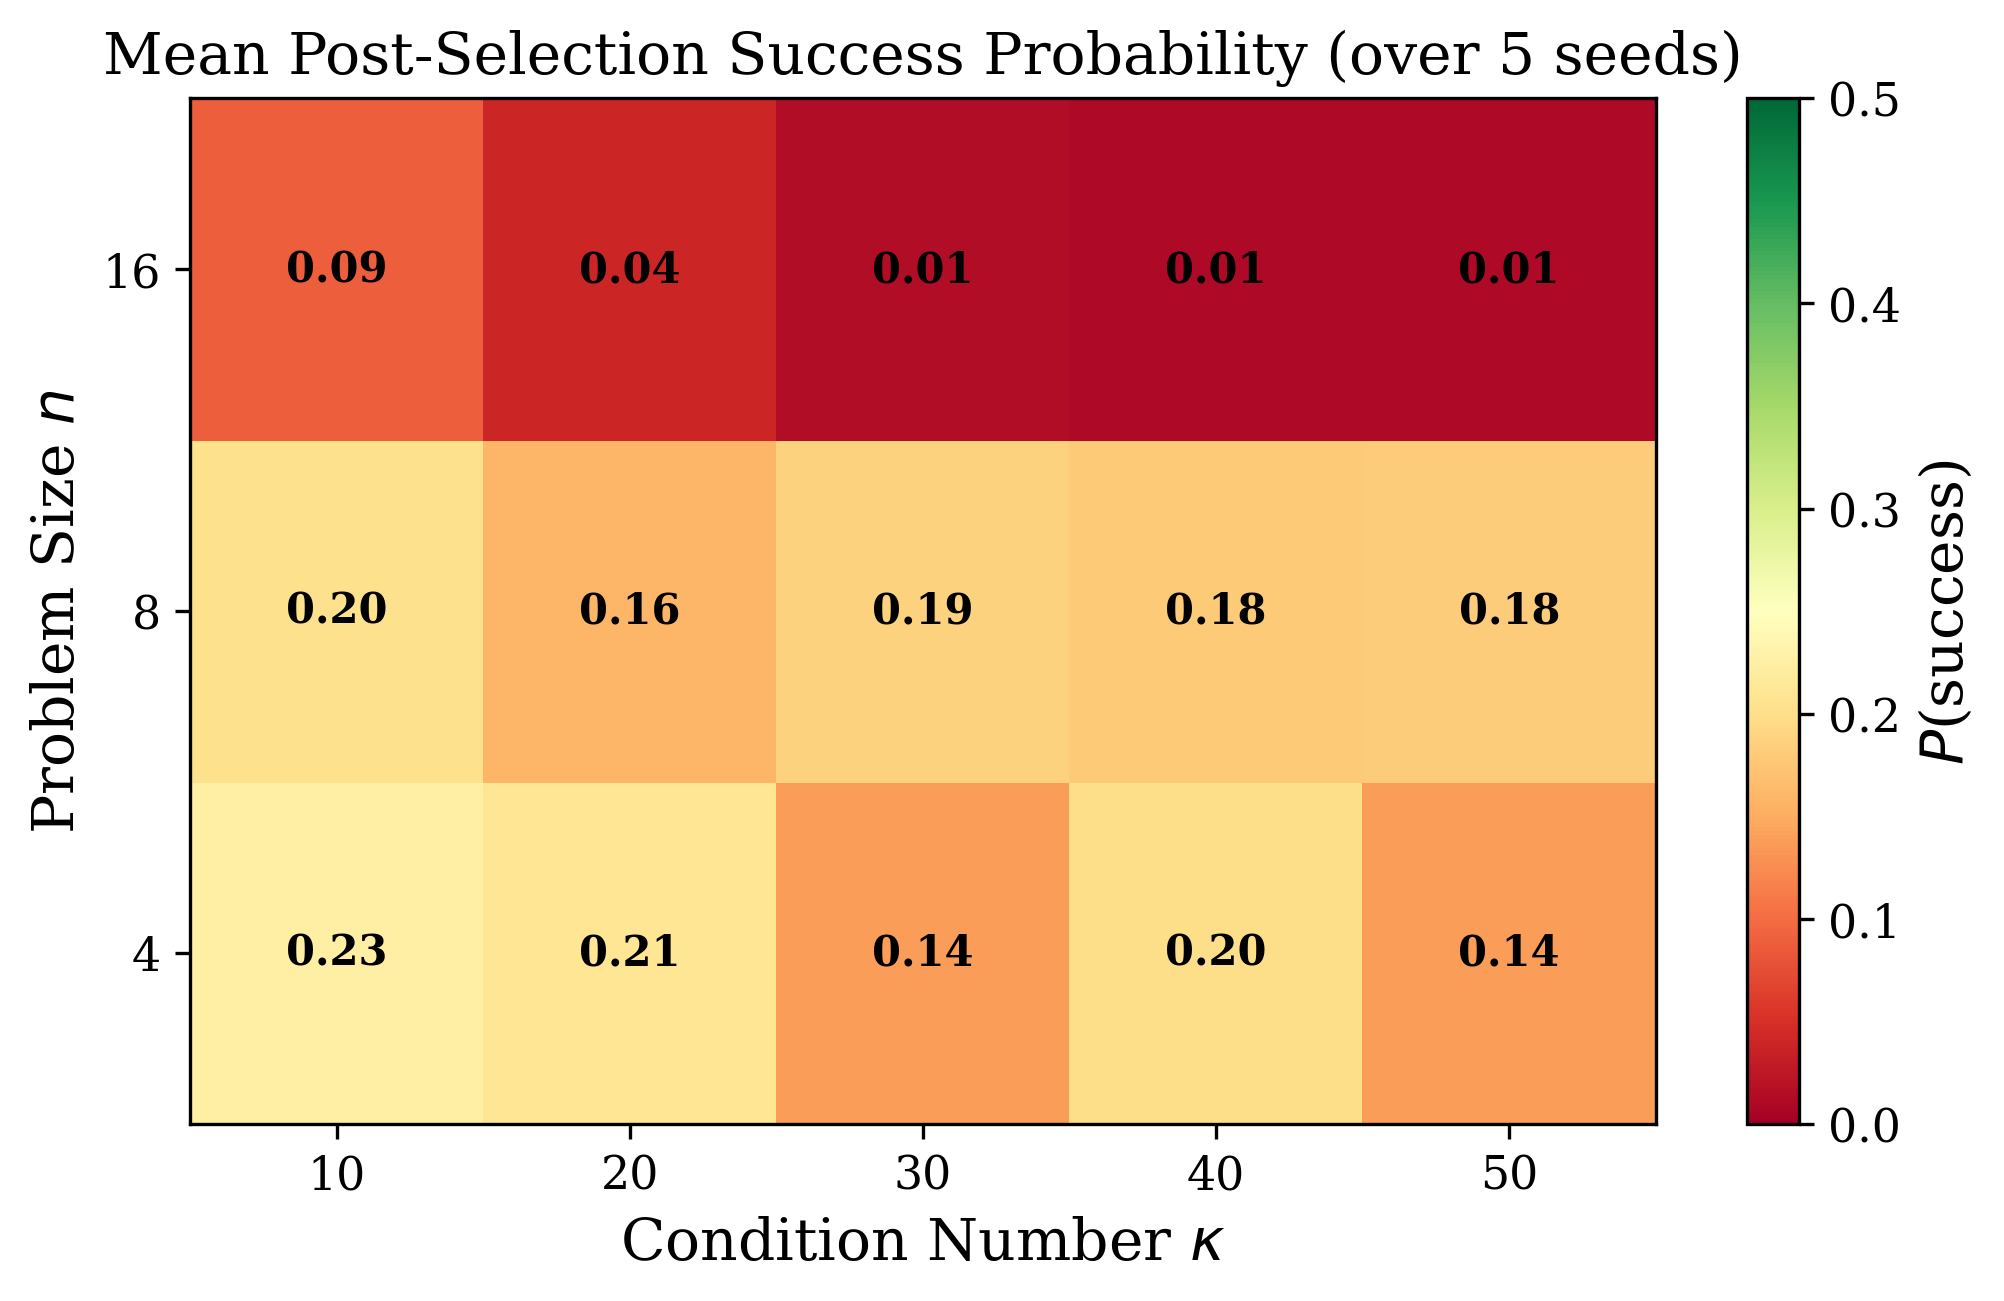

In [20]:
mean_prob = np.full((len(n_values), len(kappa_values)), np.nan)
for i, n in enumerate(n_values):
    for j, kappa in enumerate(kappa_values):
        probs = get_success_prob_matrix(results, n, kappa, num_seeds, max_iter)
        mean_prob[i, j] = np.nanmean(probs)

fig, ax = plt.subplots(figsize=(7, 4.5))
im = ax.imshow(
    mean_prob,
    origin="lower",
    aspect="auto",
    cmap="RdYlGn",
    interpolation="nearest",
    vmin=0,
    vmax=max(0.5, np.nanmax(mean_prob) * 1.1),
)

for i in range(len(n_values)):
    for j in range(len(kappa_values)):
        val = mean_prob[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=10, fontweight="bold")

ax.set_xticks(range(len(kappa_values)))
ax.set_xticklabels([str(k) for k in kappa_values])
ax.set_yticks(range(len(n_values)))
ax.set_yticklabels([str(n) for n in n_values])
ax.set_xlabel(r"Condition Number $\kappa$")
ax.set_ylabel("Problem Size $n$")
ax.set_title(rf"Mean Post-Selection Success Probability (over {num_seeds} seeds)")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("$P$(success)")

plt.tight_layout()
plt.savefig(
    f"../data/sensitivity_success_prob_{backend.name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pdf"
)
plt.show()


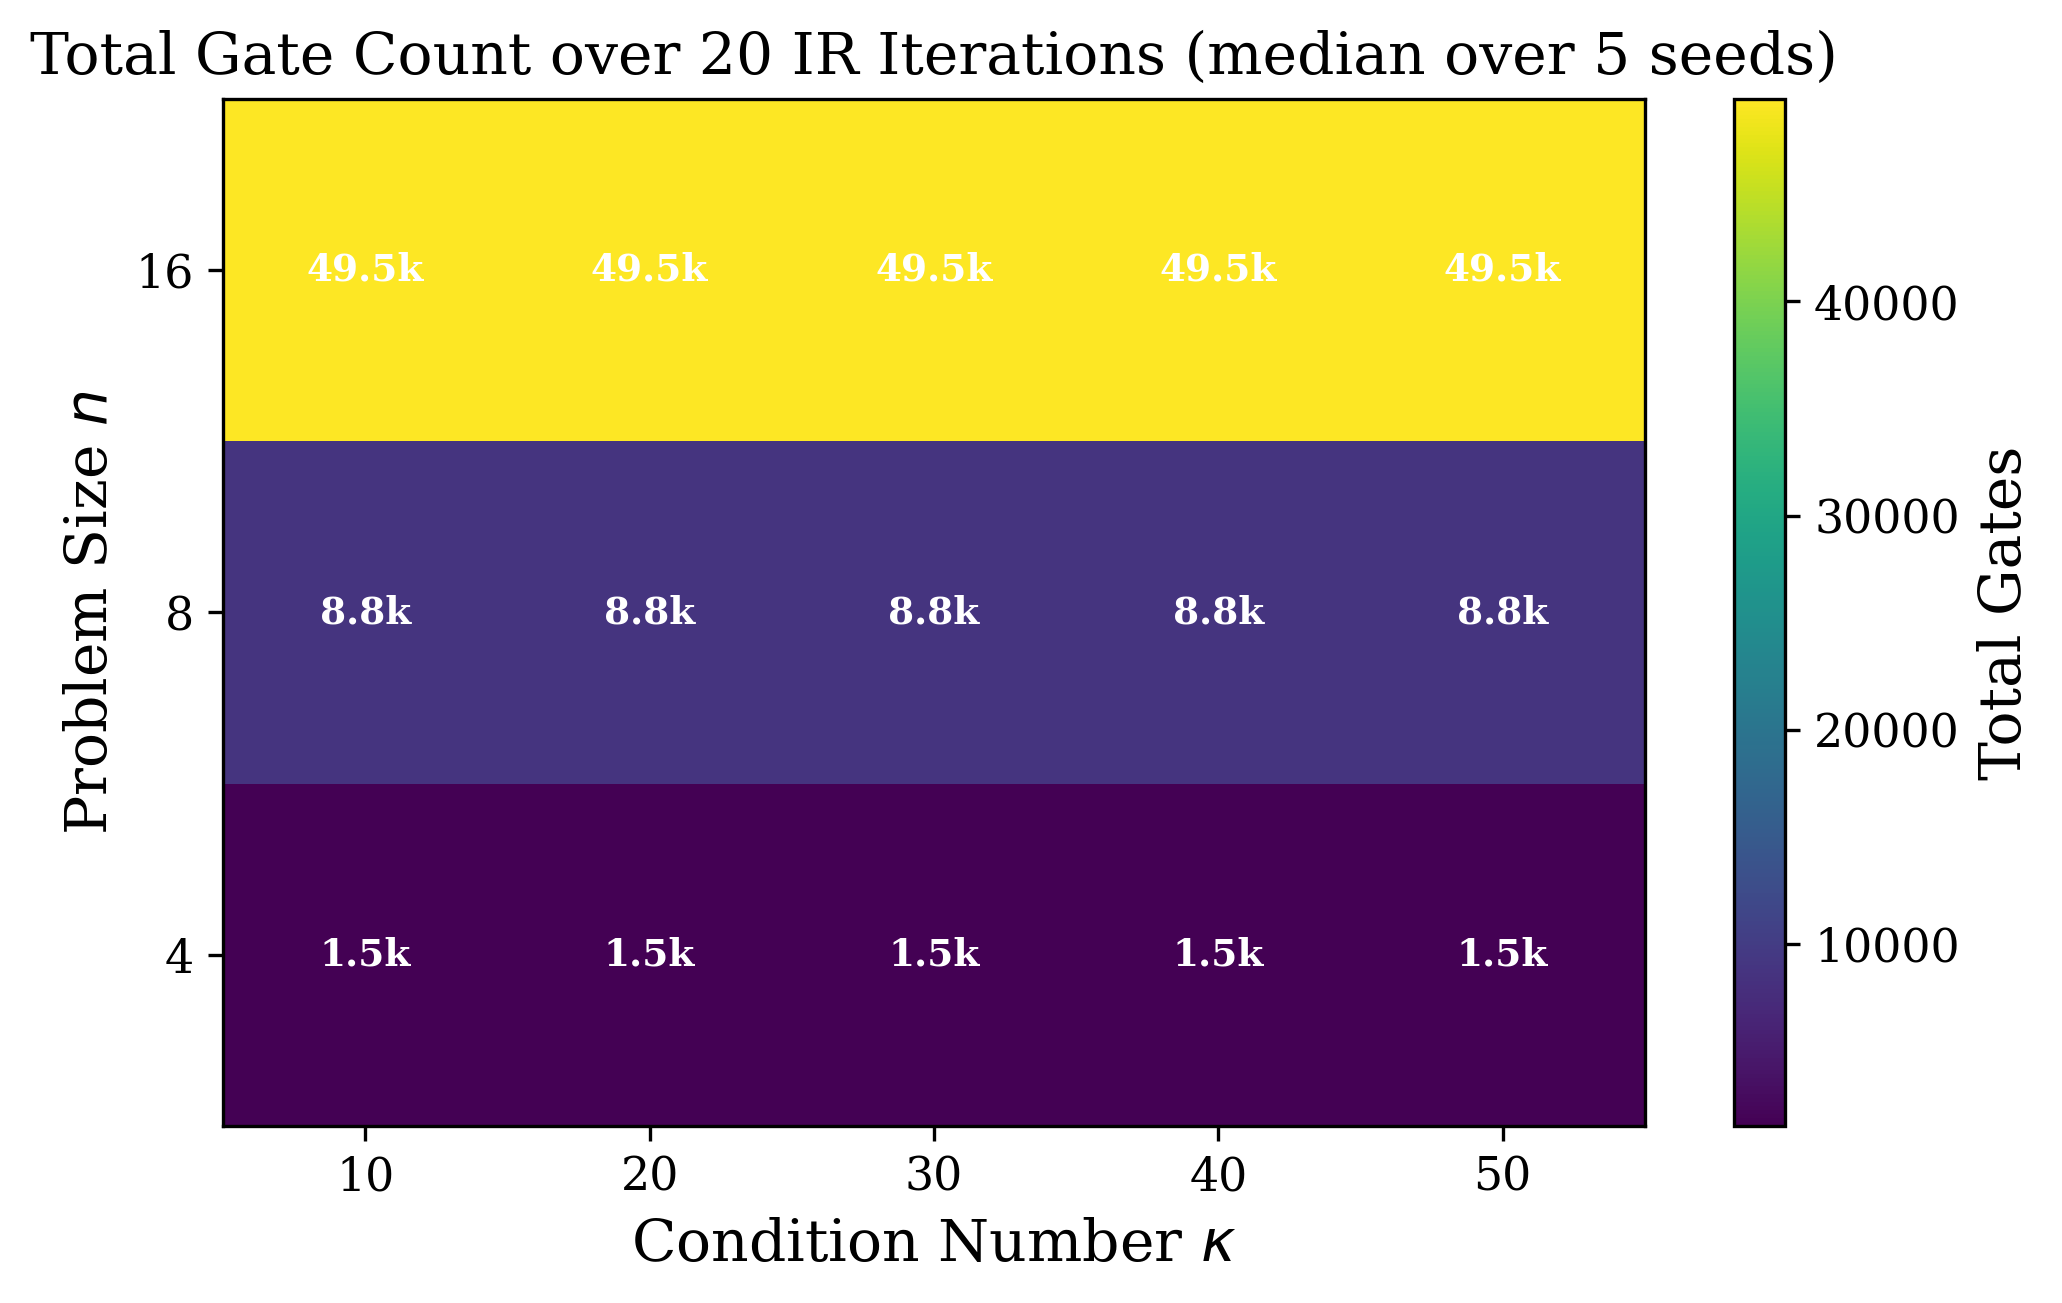

In [21]:
total_gates_grid = np.full((len(n_values), len(kappa_values)), np.nan)
for i, n in enumerate(n_values):
    for j, kappa in enumerate(kappa_values):
        gates = get_circuit_meta_matrix(results, n, kappa, num_seeds, max_iter, "gate_count")
        total_per_seed = np.nansum(gates, axis=1)
        total_gates_grid[i, j] = np.nanmedian(total_per_seed)

fig, ax = plt.subplots(figsize=(7, 4.5))
im = ax.imshow(
    total_gates_grid,
    origin="lower",
    aspect="auto",
    cmap="viridis",
    interpolation="nearest",
)

for i in range(len(n_values)):
    for j in range(len(kappa_values)):
        val = total_gates_grid[i, j]
        ax.text(j, i, f"{val/1000:.1f}k", ha="center", va="center",
                fontsize=9, fontweight="bold", color="white")

ax.set_xticks(range(len(kappa_values)))
ax.set_xticklabels([str(k) for k in kappa_values])
ax.set_yticks(range(len(n_values)))
ax.set_yticklabels([str(n) for n in n_values])
ax.set_xlabel(r"Condition Number $\kappa$")
ax.set_ylabel("Problem Size $n$")
ax.set_title(rf"Total Gate Count over {max_iter} IR Iterations (median over {num_seeds} seeds)")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Total Gates")

plt.tight_layout()
plt.savefig(
    f"../data/sensitivity_total_gates_{backend.name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pdf"
)
plt.show()
